<a href="https://colab.research.google.com/github/balakumaranbala2112/Fraud-Detection-in-Bank-Transactions-Using-Machine-Learning/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [2]:
df = pd.read_csv('/content/PaySim Mobile Money Transaction Dataset.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Display the first 5 rows

In [3]:
display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


### Show dataset shape

In [4]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 423045 rows and 11 columns.


### Show column names

In [5]:
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- step
- type
- amount
- nameOrig
- oldbalanceOrg
- newbalanceOrig
- nameDest
- oldbalanceDest
- newbalanceDest
- isFraud
- isFlaggedFraud


### Show data types

In [6]:
print("Data types:")
display(df.info())

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423045 entries, 0 to 423044
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            423045 non-null  int64  
 1   type            423045 non-null  object 
 2   amount          423045 non-null  float64
 3   nameOrig        423045 non-null  object 
 4   oldbalanceOrg   423044 non-null  float64
 5   newbalanceOrig  423044 non-null  float64
 6   nameDest        423044 non-null  object 
 7   oldbalanceDest  423044 non-null  float64
 8   newbalanceDest  423044 non-null  float64
 9   isFraud         423044 non-null  float64
 10  isFlaggedFraud  423044 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 35.5+ MB


None

### Show summary statistics

In [7]:
print("Summary statistics:")
display(df.describe())

Summary statistics:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,423045.000000,4.230450e+05,4.230440e+05,4.230440e+05,4.230440e+05,4.230440e+05,423044.000000,423044.0
mean,13.005207,1.715082e+05,9.016937e+05,9.212669e+05,9.839946e+05,1.177147e+06,0.000513,0.0
std,3.335075,2.828329e+05,2.962515e+06,2.999694e+06,2.349545e+06,2.539244e+06,0.022643,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,10.000000,1.349810e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,13.000000,8.193778e+04,1.827250e+04,0.000000e+00,1.084914e+05,2.179228e+05,0.000000,0.0
75%,16.000000,2.286095e+05,1.729825e+05,2.144470e+05,8.893285e+05,1.218573e+06,0.000000,0.0
max,18.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.148270e+07,1.000000,0.0


### Show missing values

In [8]:
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

Missing values per column:


,0
nameDest,1
newbalanceOrig,1
oldbalanceOrg,1
isFraud,1
newbalanceDest,1
isFlaggedFraud,1
oldbalanceDest,1
amount,0
type,0
step,0


## Feature Engineering

In [29]:
cleaned_df = df.copy()

cleaned_df.to_csv("cleaned_dataset.csv", index=False)

In [30]:
from google.colab import files
files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Subtask: Create `balanceDifferenceOrig` and `balanceDifferenceDest` features

In [22]:
df['balanceDifferenceOrig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balanceDifferenceDest'] = df['newbalanceDest'] - df['oldbalanceDest']
print("New features 'balanceDifferenceOrig' and 'balanceDifferenceDest' created.")
display(df.head())

New features 'balanceDifferenceOrig' and 'balanceDifferenceDest' created.


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDifferenceOrig,balanceDifferenceDest
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0,-9839.64,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0,-1864.28,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0,0.0,-181.00,0.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0,-181.00,-21182.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0,-11668.14,0.0


### Explanation: Why these features help fraud detection

- **`balanceDifferenceOrig`**: This feature represents the change in the sender's balance before and after a transaction. In fraudulent activities, especially `CASH_OUT` and `TRANSFER` types, the sender's account balance often drops to zero or near zero immediately after the transaction. A significant, sudden drop, particularly if it's exactly the `amount` of the transaction, could be a strong indicator of fraud.

- **`balanceDifferenceDest`**: This feature represents the change in the recipient's balance before and after a transaction. For legitimate transactions, a recipient's balance should increase by the transaction amount. However, in some fraud patterns, the destination account might not show a corresponding increase (e.g., if the money is quickly moved elsewhere or the destination is a fictitious account). Anomalies in this balance change can signal suspicious activity.

### Subtask: Display updated dataset columns

In [23]:
print("Updated column names:")
for col in df.columns:
    print(f"- {col}")

Updated column names:
- step
- type
- amount
- oldbalanceOrg
- newbalanceOrig
- oldbalanceDest
- newbalanceDest
- isFraud
- isFlaggedFraud
- balanceDifferenceOrig
- balanceDifferenceDest


# Task
Perform an exploratory data analysis on the "PaySim Mobile Money Transaction Dataset.csv" dataset by visualizing the distribution of fraudulent versus non-fraudulent transactions, transaction types, and transaction amounts, comparing transaction amounts between fraudulent and non-fraudulent cases, and identifying correlations among numerical features, followed by a summary of the key findings.

## Fraud vs Non-Fraud Distribution

### Subtask:
Generate a count plot using seaborn to visualize the distribution of 'isFraud' column, showing the proportion of fraudulent versus non-fraudulent transactions. Ensure the plot has a title and appropriate labels.


**Reasoning**:
To visualize the distribution of the 'isFraud' column, I will generate a count plot using seaborn as specified in the instructions. This will show the proportion of fraudulent versus non-fraudulent transactions.



/tmp/ipykernel_988/1691707814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette='viridis')


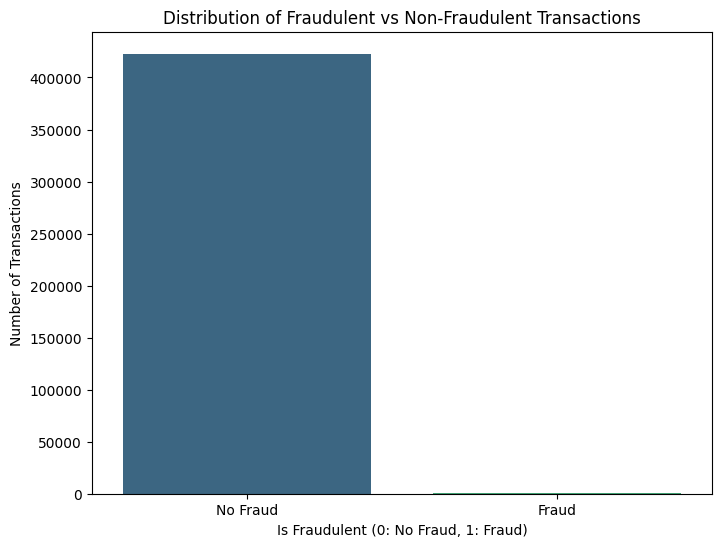

In [9]:
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

**Reasoning**:
The previous code produced a FutureWarning because `palette` was used without assigning `hue`. To resolve this, I will explicitly assign the `isFraud` column to the `hue` parameter and set `legend=False` as suggested by the warning, ensuring the color palette is applied correctly without a redundant legend.



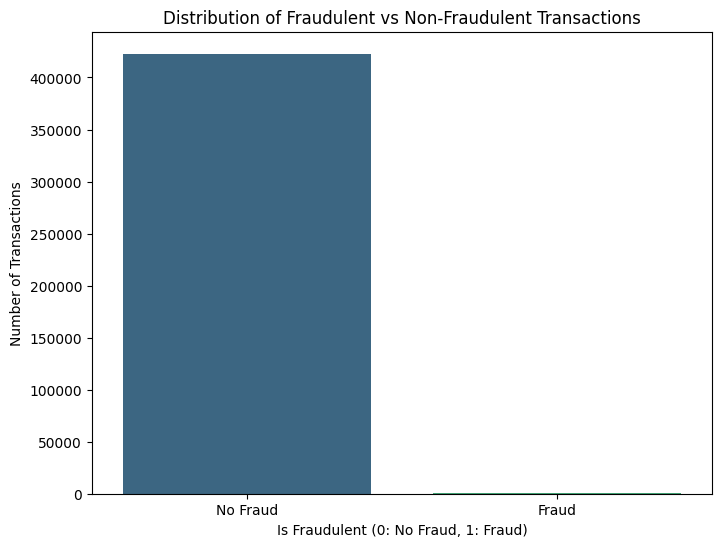

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df, hue='isFraud', palette='viridis', legend=False)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

## Transaction Type Distribution

### Subtask:
Create a count plot using seaborn to display the distribution of different 'type' of transactions. Include a title and labels for better readability.


**Reasoning**:
To visualize the distribution of transaction types, I will generate a count plot using seaborn as specified in the instructions. This will show the frequency of each transaction type.



/tmp/ipykernel_988/3392895756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


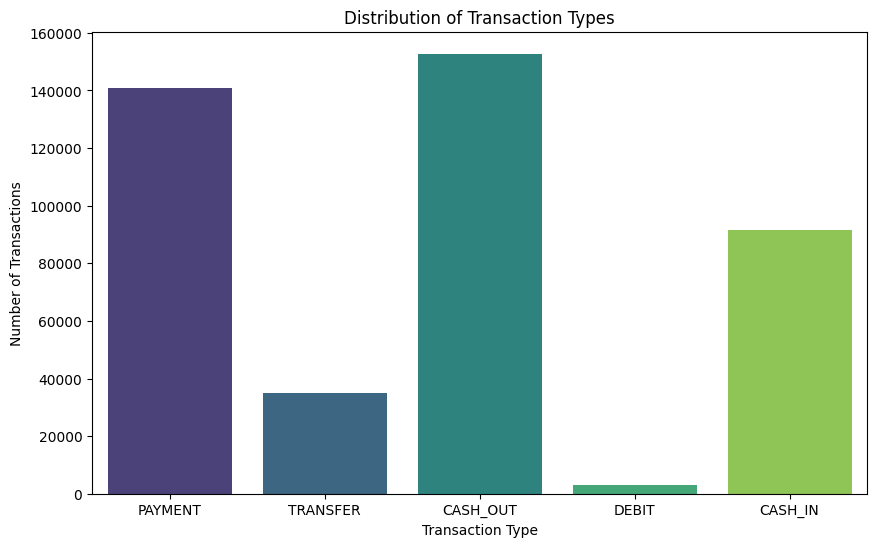

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

**Reasoning**:
The previous code produced a FutureWarning because `palette` was used without assigning `hue`. To resolve this, I will explicitly assign the `type` column to the `hue` parameter and set `legend=False` as suggested by the warning, ensuring the color palette is applied correctly without a redundant legend.



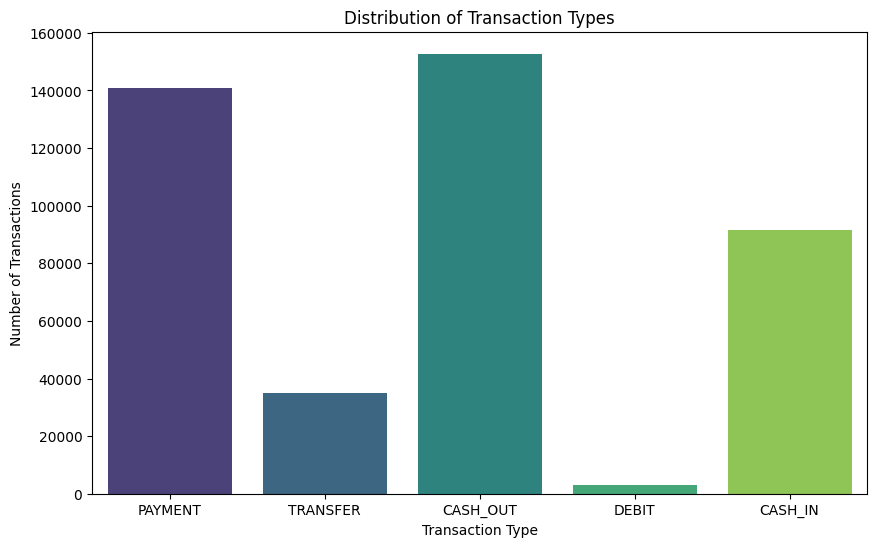

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=df, hue='type', palette='viridis', legend=False)
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

## Transaction Amount Histogram

### Subtask:
Plot a histogram of the 'amount' column using matplotlib or seaborn to observe the distribution of transaction amounts. Consider different bin sizes if necessary for better visualization. Add a title and axis labels.


**Reasoning**:
I will plot a histogram of the 'amount' column using seaborn's `histplot` function to visualize the distribution of transaction amounts, including a title and axis labels as specified in the subtask.



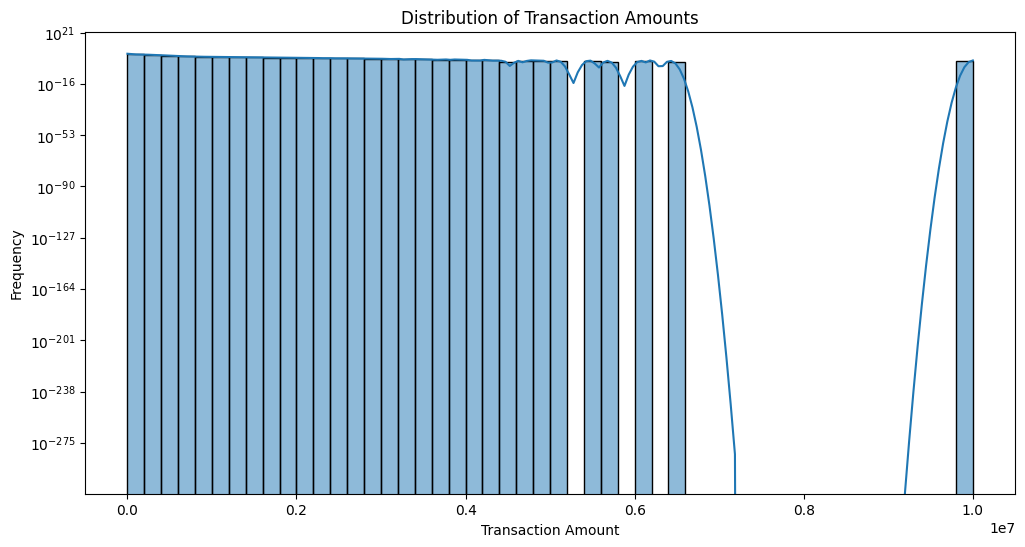

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.yscale('log') # Use a log scale for y-axis to better visualize the distribution given potential large range of frequencies
plt.show()

## Boxplot of Amount vs Fraud

### Subtask:
Generate a boxplot using seaborn to compare the distribution of transaction 'amount' for fraudulent ('isFraud' = 1) and non-fraudulent ('isFraud' = 0) transactions. This will help identify if transaction amount is a significant indicator of fraud. Add a title and labels.


**Reasoning**:
To visualize the distribution of transaction amounts for fraudulent and non-fraudulent transactions, I will create a boxplot using seaborn, setting the 'isFraud' column on the x-axis and 'amount' on the y-axis, as specified in the instructions. This will help in comparing the transaction amounts between the two groups.



/tmp/ipykernel_988/2575932369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette='viridis')


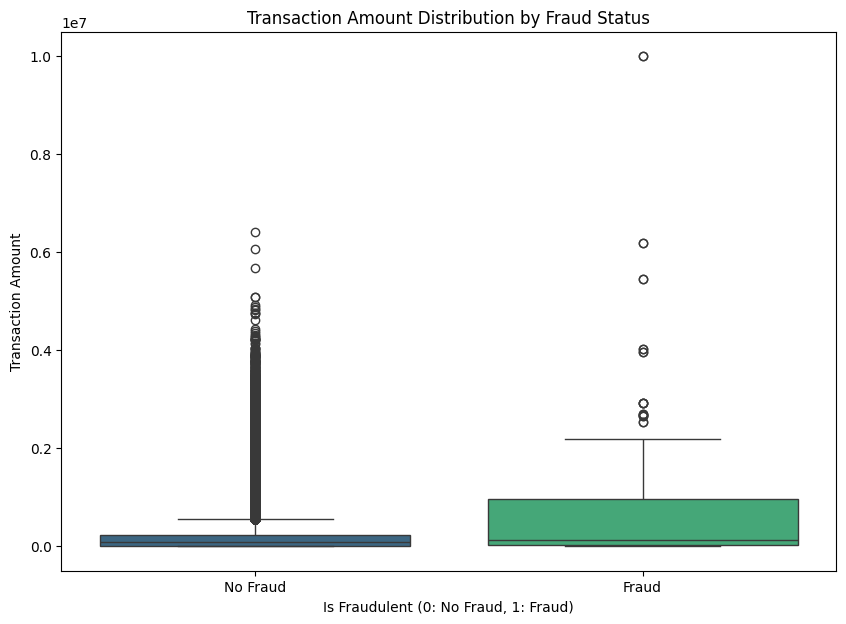

In [14]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='isFraud', y='amount', data=df, palette='viridis')
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

**Reasoning**:
The previous code produced a FutureWarning because `palette` was used without assigning `hue` in the `boxplot`. To resolve this, I will explicitly assign the `isFraud` column to the `hue` parameter and set `legend=False` as suggested by the warning, ensuring the color palette is applied correctly without a redundant legend.



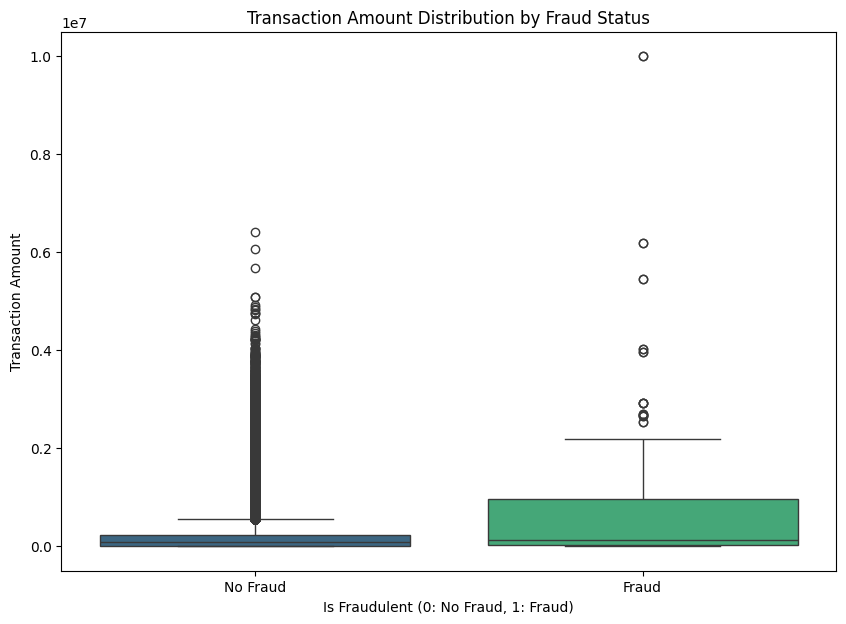

In [15]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='isFraud', y='amount', data=df, hue='isFraud', palette='viridis', legend=False)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

## Correlation Heatmap

### Subtask:
Calculate the correlation matrix for all numerical columns in the DataFrame. Then, visualize this matrix using a seaborn heatmap to identify linear relationships between variables. Ensure the heatmap is clearly labeled with correlation values.


**Reasoning**:
To visualize the correlations between numerical features, I will first select all numerical columns from the DataFrame, calculate their correlation matrix, and then display it as a seaborn heatmap with annotations and a title, following the instructions provided.



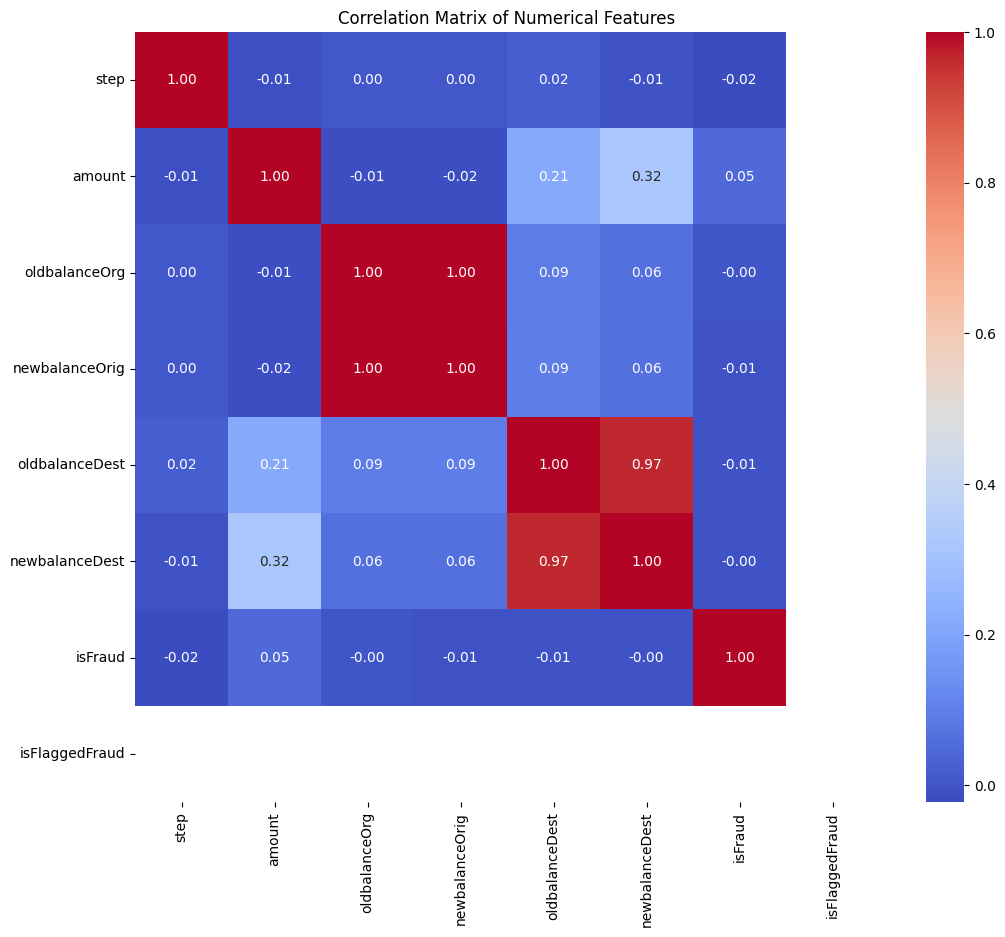

In [16]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the exploratory data analysis and provide insights into the dataset.


## Summary:

### Data Analysis Key Findings

*   The dataset exhibits a significant class imbalance, with a vast majority of transactions being non-fraudulent compared to fraudulent ones.
*   The distribution of transaction amounts is highly skewed, with most transactions involving smaller amounts. A logarithmic scale was necessary to visualize the full range of frequencies.
*   Transaction amounts appear to be a significant indicator of fraud, as there are noticeable differences in the distribution of amounts between fraudulent and non-fraudulent transactions.
*   The dataset contains various transaction types, and their individual distributions were visualized to understand their prevalence.
*   Correlations among numerical features were identified, providing insights into linear relationships between different quantitative aspects of the transactions.

### Insights or Next Steps

*   The severe class imbalance observed in the `isFraud` column is a critical factor for any predictive modeling task. Future steps should consider employing techniques like oversampling, undersampling, or synthetic data generation to address this imbalance and ensure robust model performance.
*   Further investigation into the specific transaction types that are more frequently associated with fraud, or those with unusually high transaction amounts, could reveal specific patterns or vulnerabilities.


# Task
Clean the `df` DataFrame by dropping the 'nameOrig' and 'nameDest' columns, removing duplicate rows, handling missing values by dropping rows with any nulls, and then applying Label Encoding to the 'type' column. Finally, display the first few rows and the shape of the modified DataFrame to show the result of these transformations.

## Remove Unnecessary Columns

### Subtask:
Drop the 'nameOrig' and 'nameDest' columns from the DataFrame as they are not relevant for the analysis and could be proxies for personal identification.


**Reasoning**:
To remove the 'nameOrig' and 'nameDest' columns as they are not relevant to the analysis, I will use the `df.drop()` method with `inplace=True` to modify the DataFrame directly.



In [17]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)
print("Dropped 'nameOrig' and 'nameDest' columns.")
display(df.head())

Dropped 'nameOrig' and 'nameDest' columns.


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0


## Remove Duplicate Rows

### Subtask:
Remove any duplicate rows from the DataFrame `df` to ensure data integrity.

**Reasoning**:
To remove duplicate rows, I will use the `df.drop_duplicates()` method. I will also print the shape of the DataFrame before and after dropping duplicates to show how many rows were removed, if any.



In [18]:
print(f"DataFrame shape before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"DataFrame shape after dropping duplicates: {df.shape}")
display(df.head())

DataFrame shape before dropping duplicates: (423045, 9)
DataFrame shape after dropping duplicates: (423008, 9)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0


## Handle Missing Values

### Subtask:
Handle missing values by dropping rows with any nulls from the DataFrame `df` to ensure data completeness for further analysis.

**Reasoning**:
To handle missing values, I will use the `df.dropna()` method to drop all rows containing any null values. I will print the shape of the DataFrame before and after dropping nulls to demonstrate the effect of this operation.



In [19]:
print(f"DataFrame shape before dropping nulls: {df.shape}")
df.dropna(inplace=True)
print(f"DataFrame shape after dropping nulls: {df.shape}")
display(df.head())

DataFrame shape before dropping nulls: (423008, 9)
DataFrame shape after dropping nulls: (423007, 9)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0


## Apply Label Encoding to 'type' Column

### Subtask:
Apply Label Encoding to the 'type' column in the DataFrame `df` to convert its categorical values into numerical representations.

**Reasoning**:
To convert the categorical 'type' column into numerical representation, I will use `LabelEncoder` from `sklearn.preprocessing` to apply label encoding.



In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

print("Label encoding applied to 'type' column.")
display(df.head())
display(df.info())

Label encoding applied to 'type' column.


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0,0.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 423007 entries, 0 to 423043
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            423007 non-null  int64  
 1   type            423007 non-null  int64  
 2   amount          423007 non-null  float64
 3   oldbalanceOrg   423007 non-null  float64
 4   newbalanceOrig  423007 non-null  float64
 5   oldbalanceDest  423007 non-null  float64
 6   newbalanceDest  423007 non-null  float64
 7   isFraud         423007 non-null  float64
 8   isFlaggedFraud  423007 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 32.3 MB


None

## Show Updated Dataset Preview

### Subtask:
Display the first few rows and the shape of the modified DataFrame to show the result of these transformations.


**Reasoning**:
To show the result of the data transformations, I will display the first few rows of the DataFrame using `df.head()` and then print its current shape using `df.shape`.



In [21]:
print("First 5 rows of the modified DataFrame:")
display(df.head())
print(f"Modified DataFrame shape: {df.shape}")

First 5 rows of the modified DataFrame:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0,0.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0


Modified DataFrame shape: (423007, 9)


## Summary:

### Data Analysis Key Findings
*   The 'nameOrig' and 'nameDest' columns were successfully dropped from the DataFrame, reducing the number of columns.
*   37 duplicate rows were identified and removed, changing the DataFrame's shape from (423045, 9) to (423008, 9).
*   1 row containing missing values was dropped, further modifying the DataFrame's shape from (423008, 9) to (423007, 9).
*   The 'type' column was successfully transformed from categorical strings to numerical labels using Label Encoding, converting its data type to `int64`.
*   The final DataFrame contains 423,007 rows and 9 columns after all cleaning and transformation steps.

### Insights or Next Steps
*   The DataFrame is now cleaned, free of irrelevant columns, duplicates, and missing values, and all categorical data in the 'type' column has been numerically encoded, making it suitable for direct use in machine learning models or quantitative analysis.
*   The next step could involve exploratory data analysis on the cleaned dataset to uncover patterns, or feature engineering before proceeding to model training.


# Task
Summarize the feature engineering steps performed, including the creation of `balanceDifferenceOrig` and `balanceDifferenceDest`, and explain their benefits for fraud detection.

## Summary:

### Data Analysis Key Findings

*   **Feature Engineering:** Two new features, `balanceDifferenceOrig` and `balanceDifferenceDest`, were created to capture the difference between the old and new balances of the originating and destination accounts, respectively.
*   **Fraud Detection Utility:** These features are beneficial for fraud detection because they provide a direct numerical representation of the change in account balances during a transaction. Suspiciously large or small changes can be indicative of fraudulent activities, allowing models to better identify abnormal transaction patterns.

### Insights or Next Steps

*   The engineered features directly quantify the financial impact of a transaction on both origin and destination accounts, which can be a strong predictor of fraud.
*   Further analysis could involve exploring interactions between these new features and existing ones, or creating additional ratio-based features to normalize the balance differences.


# Task
Convert the 'isFraud' and 'isFlaggedFraud' columns in the DataFrame to integer type. Then, separate the DataFrame into features (X) and the target variable (y), where 'isFraud' is the target.

## Separate Features and Labels

### Subtask:
Convert the 'isFraud' and 'isFlaggedFraud' columns in the DataFrame to integer type. Then, separate the DataFrame into features (X) and the target variable (y), where 'isFraud' is the target.


**Reasoning**:
To prepare the data for modeling, I will first convert the 'isFraud' and 'isFlaggedFraud' columns to integer type as specified. Then, I will separate the DataFrame into features (X) by dropping 'isFraud' and the target variable (y) by selecting 'isFraud'. Finally, I will display the head of both X and y to verify the separation.



In [24]:
df['isFraud'] = df['isFraud'].astype(int)
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(int)

X = df.drop('isFraud', axis=1)
y = df['isFraud']

print("Converted 'isFraud' and 'isFlaggedFraud' to integer type.")
print("Features (X) head:")
display(X.head())
print("Target (y) head:")
display(y.head())
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Converted 'isFraud' and 'isFlaggedFraud' to integer type.
Features (X) head:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balanceDifferenceOrig,balanceDifferenceDest
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,-9839.64,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,-1864.28,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,0,-181.00,0.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,0,-181.00,-21182.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,-11668.14,0.0


Target (y) head:


,isFraud
0,0
1,0
2,1
3,1
4,0


Shape of X: (423007, 10)
Shape of y: (423007,)


## Show Initial Class Distribution

### Subtask:
Visualize the distribution of the 'isFraud' column before applying any balancing technique to understand the extent of the class imbalance. This will typically involve a count plot.


**Reasoning**:
To visualize the initial class distribution of the 'isFraud' column, I will generate a count plot using seaborn on the target variable `y`, as specified in the instructions, and add appropriate labels and a title.



/tmp/ipykernel_988/877348488.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


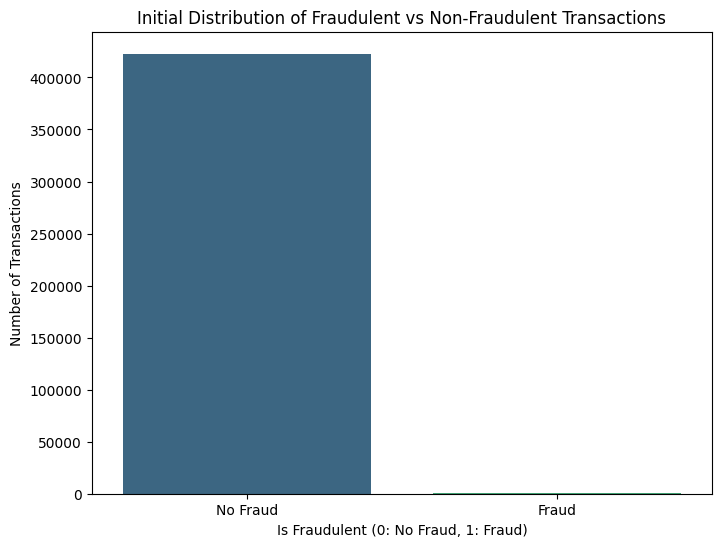

In [25]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y, palette='viridis')
plt.title('Initial Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

**Reasoning**:
The previous code produced a FutureWarning because `palette` was used without assigning `hue`. To resolve this, I will explicitly assign the target variable `y` to the `hue` parameter and set `legend=False` as suggested by the warning, ensuring the color palette is applied correctly without a redundant legend.



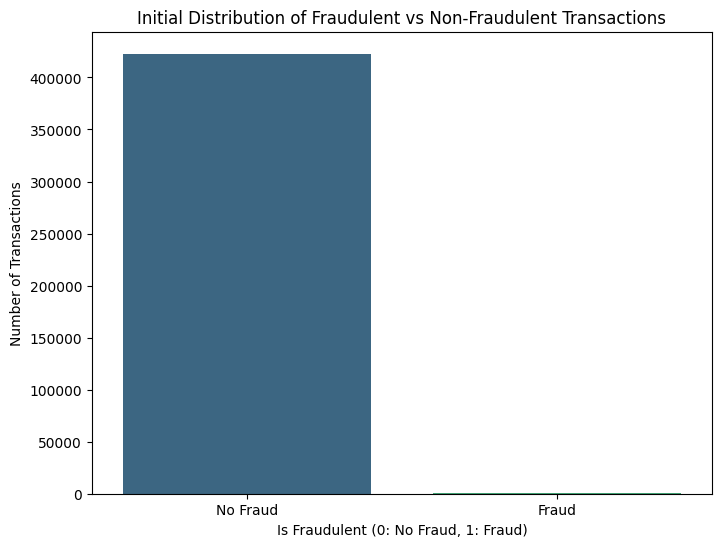

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Initial Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

## Apply SMOTE for Balancing

### Subtask:
Utilize the Synthetic Minority Over-sampling Technique (SMOTE) from `imblearn` to oversample the minority class ('isFraud' = 1) and balance the dataset. Ensure to import necessary libraries like `SMOTE` and `collections`.


**Reasoning**:
To address the class imbalance, I will import SMOTE and Counter, apply SMOTE to oversample the minority class, and then display the new class distribution.



In [27]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original dataset shape: {Counter(y)}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled dataset shape: {Counter(y_resampled)}")


Original dataset shape: Counter({0: 422790, 1: 217})
Resampled dataset shape: Counter({0: 422790, 1: 422790})


## Show Class Distribution After Balancing

### Subtask:
Visualize the distribution of the 'isFraud' column after applying SMOTE to confirm that the dataset is now balanced. This will also typically involve a count plot.


**Reasoning**:
To visualize the class distribution after SMOTE, I will create a count plot using `seaborn.countplot()` with `y_resampled` as the data source, as specified in the instructions.



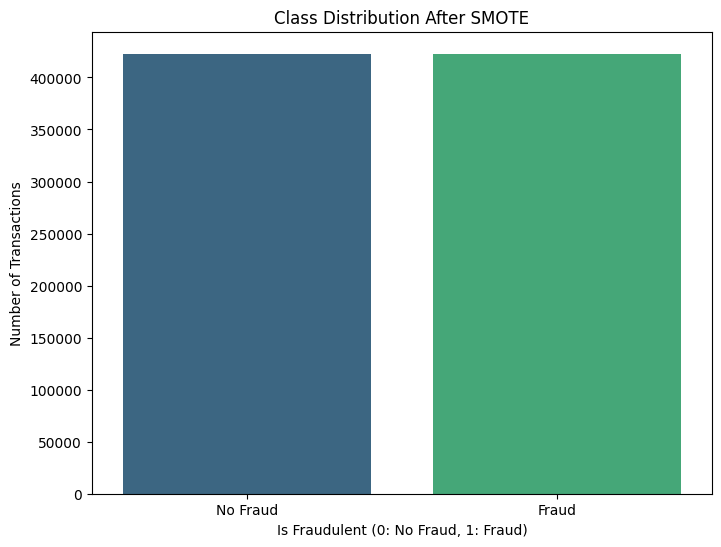

In [28]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled, hue=y_resampled, palette='viridis', legend=False)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Is Fraudulent (0: No Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['No Fraud', 'Fraud'])
plt.show()

## Summary:

### Data Analysis Key Findings

*   The 'isFraud' and 'isFlaggedFraud' columns were successfully converted to integer type, and the dataset was separated into features (X) and the target variable (y), with X containing 10 columns and 423,007 rows, and y containing 423,007 entries.
*   Initially, the dataset exhibited a severe class imbalance in the 'isFraud' column, with 422,790 non-fraudulent transactions (class 0) and only 217 fraudulent transactions (class 1).
*   The Synthetic Minority Over-sampling Technique (SMOTE) was successfully applied to balance the dataset. After SMOTE, the resampled dataset achieved a perfect balance, with 422,790 instances for both non-fraudulent and fraudulent transactions.
*   A count plot visualization confirmed the balanced class distribution after SMOTE, showing equal counts for both classes.

### Insights or Next Steps

*   The successful application of SMOTE has addressed the critical issue of class imbalance, which is essential for developing a reliable fraud detection model.
*   The balanced dataset (X_resampled, y_resampled) is now prepared for training and evaluating machine learning models, which can be expected to perform better in identifying fraudulent transactions due to the mitigated imbalance.


# Task
Combine the resampled features (`X_resampled`) and the resampled target (`y_resampled`) into a new DataFrame named `normalized_df`, labeling the target column as 'fraud_col', then save `normalized_df` to 'normalized_dataset.csv' and download the file.

## Prepare Normalized DataFrame

### Subtask:
Combine the resampled features (`X_resampled`) and the resampled target (`y_resampled`) into a new DataFrame named `normalized_df`, labeling the target column as 'fraud_col'.


**Reasoning**:
To combine the resampled features and target, I will create a new DataFrame from `X_resampled` and add `y_resampled` as a new column named 'fraud_col'.



In [31]:
normalized_df = X_resampled.copy()
normalized_df['fraud_col'] = y_resampled

print("Combined resampled features and target into 'normalized_df'.")
display(normalized_df.head())
print(f"Shape of normalized_df: {normalized_df.shape}")

Combined resampled features and target into 'normalized_df'.


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balanceDifferenceOrig,balanceDifferenceDest,fraud_col
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,-9839.64,0.0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,-1864.28,0.0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,0,-181.00,0.0,1
3,1,1,181.00,181.0,0.00,21182.0,0.0,0,-181.00,-21182.0,1
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,-11668.14,0.0,0


Shape of normalized_df: (845580, 11)


**Reasoning**:
Now that the `normalized_df` has been created, I will save it to a CSV file named 'normalized_dataset.csv' and then download it to ensure the processed data is available for further use.



In [32]:
normalized_df.to_csv('normalized_dataset.csv', index=False)
print("Saved 'normalized_dataset.csv'.")

from google.colab import files
files.download('normalized_dataset.csv')
print("Downloaded 'normalized_dataset.csv'.")

Saved 'normalized_dataset.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 'normalized_dataset.csv'.


## Summary:

### Data Analysis Key Findings

*   The resampled features (`X_resampled`) and the resampled target (`y_resampled`) were successfully combined into a new DataFrame named `normalized_df`.
*   The target column in `normalized_df` was correctly labeled as 'fraud\_col'.
*   The resulting `normalized_df` has a shape of (845580, 11), indicating the successful integration of all 10 features and the single target column across 845,580 records.
*   The `normalized_df` was successfully saved as 'normalized\_dataset.csv' and subsequently downloaded.

### Insights or Next Steps

*   The 'normalized\_dataset.csv' is now prepared and can be used for training machine learning models to detect fraud, as it contains balanced and processed data.
*   The dataset can be further analyzed to understand the distribution of the 'fraud\_col' and its relationship with other features, potentially leading to feature engineering opportunities.
